# OceanDataCatalog | NOC Near-Present Day

## About

This Notebook demonstrates how to use the **OceanDataCatalog** API to explore the [Near-Present-Day](https://noc-msm.github.io/NOC_Near_Present_Day/) global ocean sea-ice simulations developed by the National Oceanography Centre as part of the Atlantic Climate and Environment Strategic Science ([AtlantiS](https://noc.ac.uk/projects/atlantis)) programme.

In [1]:
from OceanDataStore import OceanDataCatalog

* Create an instance of the **OceanDataCatalog** class to access the National Oceanography Centre ocean model Spatio-Temporal Access Catalog (`noc-model-stac`):

In [2]:
catalog = OceanDataCatalog(catalog_name="noc-model-stac")

* Let's use the `.search()` method to search the Near-Present Day ERA-5 collection for all ocean model outputs including the sea surface temperature (SST) standard variable name:

In [3]:
catalog.search(collection='noc-npd-era5', standard_name='sea_surface_temperature')


            * Item ID: noc-npd-era5/npd-eorca1-era5v1/gn_global/T1y
              Title: eORCA1 ERA5v1 NPD T1y Icechunk repository
              Description: Icechunk repository containing eORCA1 ERA5v1 NPD global ocean physics annual mean outputs defined at T-points.
              Platform: gn_global
              Start Date: 1976-01-01T00:00:00Z
              End Date: 2024-12-31T00:00:00Z
            

            * Item ID: noc-npd-era5/npd-eorca1-era5v1/gn_global/T1m
              Title: eORCA1 ERA5v1 NPD T1m Icechunk repository
              Description: Icechunk repository containing eORCA1 ERA5v1 NPD global ocean physics monthly mean outputs defined at T-points.
              Platform: gn_global
              Start Date: 1976-01-01T00:00:00Z
              End Date: 2024-12-31T00:00:00Z
            

            * Item ID: noc-npd-era5/npd-eorca025-era5v1/gn_global/T1y_3d
              Title: eORCA025 ERA5v1 NPD T1y_3d Icechunk repository
              Description: Icechunk rep

* Now, let's take a closer look at the first Item in our search results. This corresponds to the annual-mean T-grid variables output by the 1-degree NPD eORCA1 ERA5v1 simulation.

* By looking in `properties/variable_standard_names`, we can see that 'sea_surface_temperature' is the 59th variable in this dataset and is named `tos_con`.

In [4]:
catalog.Items[0]

<Item id=noc-npd-era5/npd-eorca1-era5v1/gn_global/T1y>

* Next, let's open a subset (1980-1990) of the annual-mean SST data as an `xarray.Dataset` by using the `.open_dataset()` method and specifying start and end date strings. 

* Here, we use the `.id` attribute of our first *Item*, but we could have also copied the `id` string from above.

In [6]:
ds = catalog.open_dataset(id=catalog.Items[0].id,
                          start_datetime='1980-01',
                          end_datetime='1990-12',
                          )

ds

<xarray.Dataset> Size: 9GB
Dimensions:                (time_counter: 11, y: 331, x: 360, deptht: 75,
                            axis_nbounds: 2)
Coordinates:
  * deptht                 (deptht) float32 300B 0.5058 1.556 ... 5.902e+03
    nav_lat                (y, x) float64 953kB dask.array<chunksize=(331, 360), meta=np.ndarray>
    nav_lon                (y, x) float64 953kB dask.array<chunksize=(331, 360), meta=np.ndarray>
    time_centered          (time_counter) datetime64[ns] 88B dask.array<chunksize=(1,), meta=np.ndarray>
  * time_counter           (time_counter) datetime64[ns] 88B 1980-07-02 ... 1...
Dimensions without coordinates: y, x, axis_nbounds
Data variables: (12/73)
    berg_latent_heat_flux  (time_counter, y, x) float32 5MB dask.array<chunksize=(1, 331, 360), meta=np.ndarray>
    hfds                   (time_counter, y, x) float32 5MB dask.array<chunksize=(1, 331, 360), meta=np.ndarray>
    fsitherm               (time_counter, y, x) float32 5MB dask.array<chunksize=(1, 331, 360), meta=np.ndarray>
    ficeberg               (time_counter, y, x) float32 5MB dask.array<chunksize=(1, 331, 360), meta=np.ndarray>
    friver                 (time_counter, y, x) float32 5MB dask.array<chunksize=(1, 331, 360), meta=np.ndarray>
    empmr                  (time_counter, y, x) float32 5MB dask.array<chunksize=(1, 331, 360), meta=np.ndarray>
    ...                     ...
    vowflisf               (time_counter, deptht, y, x) float32 393MB dask.array<chunksize=(1, 25, 331, 360), meta=np.ndarray>
    ttrd_atf_li            (time_counter, deptht, y, x) float32 393MB dask.array<chunksize=(1, 25, 331, 360), meta=np.ndarray>
    zos                    (time_counter, y, x) float32 5MB dask.array<chunksize=(1, 331, 360), meta=np.ndarray>
    ttrd_qns_li            (time_counter, y, x) float32 5MB dask.array<chunksize=(1, 331, 360), meta=np.ndarray>
    vohfcisf               (time_counter, deptht, y, x) float32 393MB dask.array<chunksize=(1, 25, 331, 360), meta=np.ndarray>
    zossq                  (time_counter, y, x) float32 5MB dask.array<chunksize=(1, 331, 360), meta=np.ndarray>

* Finally, let's create a plot of the time-mean (1980-1990) SST for the globe:

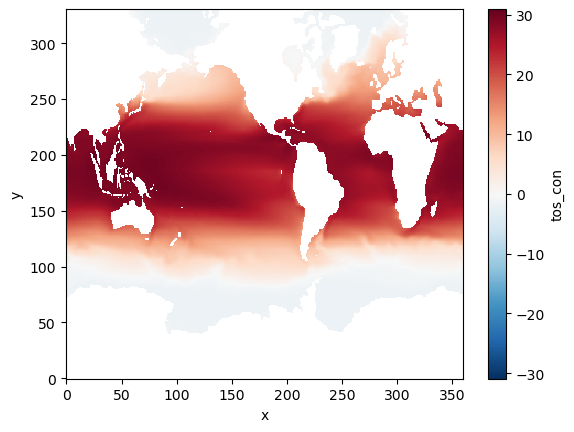

In [7]:
ds['tos_con'].mean(dim='time_counter').plot(cmap='RdBu_r')

## Pre-Calculated Diagnostics

* So far, we have seen how to access NPD ocean model variables (e.g., temperature, salinity and velocities) defined on their native NEMO model grid.

* In addition to these variables, we can also access a range of pre-calculated diagnostics, such as the meridional overturning, heat and freshwater transports across the following trans-basin sections:

    - Overturning in the Subpolar North Atlantic Program (**OSNAP**) array
    - Rapid Climate Change-Meridional Overturning Circulation and Heatflux Array (**RAPID-MOCHA**) at 26.5°N
    - Meridional Overturning Variability Experiment (**MOVE**) array at 16°N
    - South Atlantic Meridional overturning circulation Basin-wide Array (**SAMBA**) array at 34.5°S

* These diagnostics are calculated using the [Meridional ovErTurning ciRculation diagnostIC (METRIC)](https://github.com/oj-tooth/metric) package.

* Next, let's see how we can access these diagnostics by searching the `OceanDataCatalog` for any *Items* with identifiers containing the key word **"tn"**, which corresponds to transects which are defined on the native NEMO model grid:


In [8]:
catalog.search(collection='noc-npd-era5', item_name='tn')


            * Item ID: noc-npd-era5/npd-eorca1-era5v1/tn/M1m/MOVE_16N
              Title: eORCA1 ERA5v1 NPD M1m/MOVE_16N Icechunk repository
              Description: Icechunk repository containing eORCA1 ERA5v1 NPD ocean physics transect monthly mean outputs defined at MOVE_16N.
              Platform: tn
              Start Date: 1976-01-01T00:00:00Z
              End Date: 2024-12-31T00:00:00Z
            

            * Item ID: noc-npd-era5/npd-eorca1-era5v1/tn/M1m/SAMBA_34_5S
              Title: eORCA1 ERA5v1 NPD M1m/SAMBA_34_5S Icechunk repository
              Description: Icechunk repository containing eORCA1 ERA5v1 NPD global ocean scalar monthly mean outputs.
              Platform: tn
              Start Date: 1976-01-01T00:00:00Z
              End Date: 2024-12-31T00:00:00Z
            

            * Item ID: noc-npd-era5/npd-eorca1-era5v1/tn/M1m/RAPID_26N
              Title: eORCA1 ERA5v1 NPD M1m/RAPID_26N Icechunk repository
              Description: Icechunk repo

* We can see from the list of search *Items* that `OSNAP`, `RAPID_26N`, `MOVE_16N` and `SAMBA_34_5S` diagnostics are available for all NPD model configurations.

* Now, let's open the `RAPID_26N` file for the 1-degree NPD eORCA1 ERA5v1 simulation we explored earlier. 

In [9]:
ds_rapid = catalog.open_dataset(id="noc-npd-era5/npd-eorca1-era5v1/tn/M1m/RAPID_26N")

ds_rapid

<xarray.Dataset> Size: 156MB
Dimensions:        (time: 588, z: 75, xbounds: 72, x: 71)
Coordinates:
  * time           (time) datetime64[ns] 5kB 1976-01-16T12:00:00 ... 2024-12-...
  * x              (x) float64 568B -80.5 -79.5 -78.5 ... -12.5 -11.5 -10.5
  * xbounds        (xbounds) float64 576B -81.0 -80.0 -79.0 ... -11.0 -9.998
  * z              (z) float64 600B 0.5058 1.556 2.668 ... 5.698e+03 5.902e+03
Data variables: (12/60)
    fw_eddy        (time) float64 5kB dask.array<chunksize=(294,), meta=np.ndarray>
    fc             (time) float64 5kB dask.array<chunksize=(294,), meta=np.ndarray>
    fw_mo          (time) float64 5kB dask.array<chunksize=(294,), meta=np.ndarray>
    fw_fc          (time) float64 5kB dask.array<chunksize=(294,), meta=np.ndarray>
    fw_ek          (time) float64 5kB dask.array<chunksize=(294,), meta=np.ndarray>
    fw_gyre_model  (time) float64 5kB dask.array<chunksize=(294,), meta=np.ndarray>
    ...             ...
    umo            (time) float64 5kB dask.array<chunksize=(294,), meta=np.ndarray>
    vgeo           (time, z, x) float64 25MB dask.array<chunksize=(1, 75, 71), meta=np.ndarray>
    v_basin_model  (time, z) float64 353kB dask.array<chunksize=(1, 75), meta=np.ndarray>
    v_fc           (time, z) float64 353kB dask.array<chunksize=(1, 75), meta=np.ndarray>
    v_basin_rapid  (time, z) float64 353kB dask.array<chunksize=(1, 75), meta=np.ndarray>
    wbw            (time) float64 5kB dask.array<chunksize=(294,), meta=np.ndarray>
Attributes:
    geostrophic_method:           bottom-up
    geostrophic_reference_level:  4820.0
    reference_to_model_velocity:  None
    eos:                          teos10
    rhocp:                        4084625.0
    ekman_level:                  100.0
    contact:                      fredc.ucar.edu
    code_reference:               https://github.com/NCAR/metric
    method_references:            (1) McCarthy, G. D., and Coauthors, 2015: M...

## Ocean Model Domain Variables

* So far, we have seen how to access NPD ocean model variables (e.g., temperature, salinity and velocities) defined on their native NEMO model grid.

* But often when calculating diagnostics derived from these variables, such as volume, heat and freshwater transports, we also need access to the variables describing the model domain.

* Let's next search the `OceanDataCatalog` for any *Items* with identifiers which contain the **"domain"** key word:

In [10]:
catalog.search(collection='noc-npd-era5', item_name='domain')


            * Item ID: noc-npd-era5/npd-eorca1-era5v1/gn_global/domain/domain_cfg
              Title: eORCA1 ERA5v1 NPD domain/domain_cfg Icechunk repository
              Description: Icechunk repository containing eORCA1 ERA5v1 NPD global ocean model domain_cfg variables.
              Platform: gn_global
              Start Date: 1976-01-01T00:00:00Z
              End Date: 2024-12-31T00:00:00Z
            

            * Item ID: noc-npd-era5/npd-eorca1-era5v1/gn_global/domain/mesh_mask
              Title: eORCA1 ERA5v1 NPD domain/mesh_mask Icechunk repository
              Description: Icechunk repository containing eORCA1 ERA5v1 NPD global ocean model mesh_mask variables.
              Platform: gn_global
              Start Date: 1976-01-01T00:00:00Z
              End Date: 2024-12-31T00:00:00Z
            

            * Item ID: noc-npd-era5/npd-eorca1-era5v1/gn_global/domain/subbasins
              Title: eORCA1 ERA5v1 NPD domain/subbasins Icechunk repository
             

* We can see from the list of search *Items* that `domain_cfg`, `mesh_mask` and `subbasin` ancillary data are available for each NPD model configuration.

* Next, let's open the `domain_cfg` file for the 1-degree NPD eORCA1 ERA5v1 simulation we explored earlier. 

In [11]:
ds_domain_cfg = catalog.open_dataset(id="noc-npd-era5/npd-eorca1-era5v1/gn_global/domain/domain_cfg")

ds_domain_cfg

<xarray.Dataset> Size: 666MB
Dimensions:        (t: 1, y: 331, x: 360, z: 75)
Dimensions without coordinates: t, y, x, z
Data variables: (12/43)
    bathy_metry    (t, y, x) float32 477kB dask.array<chunksize=(1, 331, 360), meta=np.ndarray>
    e1u            (t, y, x) float64 953kB dask.array<chunksize=(1, 331, 360), meta=np.ndarray>
    e2t            (t, y, x) float64 953kB dask.array<chunksize=(1, 331, 360), meta=np.ndarray>
    e2v            (t, y, x) float64 953kB dask.array<chunksize=(1, 331, 360), meta=np.ndarray>
    e1t            (t, y, x) float64 953kB dask.array<chunksize=(1, 331, 360), meta=np.ndarray>
    bottom_level   (t, y, x) int32 477kB dask.array<chunksize=(1, 331, 360), meta=np.ndarray>
    ...             ...
    top_level      (t, y, x) int32 477kB dask.array<chunksize=(1, 331, 360), meta=np.ndarray>
    mask_opensea   (t, y, x) int32 477kB dask.array<chunksize=(1, 331, 360), meta=np.ndarray>
    mask_csemp     (t, y, x) int32 477kB dask.array<chunksize=(1, 331, 360), meta=np.ndarray>
    mask_csglo     (t, y, x) int32 477kB dask.array<chunksize=(1, 331, 360), meta=np.ndarray>
    mask_csrnf     (t, y, x) int32 477kB dask.array<chunksize=(1, 331, 360), meta=np.ndarray>
    time_counter   (t) float64 8B dask.array<chunksize=(1,), meta=np.ndarray>
Attributes:
    DOMAIN_number_total:     1
    DOMAIN_number:           0
    DOMAIN_dimensions_ids:   [1, 2]
    DOMAIN_size_global:      [362, 332]
    DOMAIN_size_local:       [362, 332]
    DOMAIN_position_first:   [1, 1]
    DOMAIN_position_last:    [362, 332]
    DOMAIN_halo_size_start:  [0, 0]
    DOMAIN_halo_size_end:    [0, 0]
    DOMAIN_type:             BOX
    history:                 Mon Jun  5 12:41:32 2023: ncks -A mask.nc ORCA1_...
    NCO:                     4.4.7